In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import warnings
warnings.filterwarnings("ignore")

c:\Users\Urvi Patel\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
transactions.columns.tolist()

['invoice',
 'stockcode',
 'description',
 'quantity',
 'invoicedate',
 'price',
 'customer_id',
 'country',
 'is_cancelled',
 'is_return',
 'revenue',
 'year',
 'month',
 'month_name',
 'day',
 'day_name',
 'hour',
 'quarter',
 'week']

In [4]:
transactions = pd.read_csv("clean_online_retail.csv")
customer_df = pd.read_csv("customer_segments.csv")

transactions["invoice_date"] = pd.to_datetime(transactions["invoicedate"])

transactions.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,is_cancelled,is_return,revenue,year,month,month_name,day,day_name,hour,quarter,week,invoice_date
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,False,83.4,2009,12,December,1,Tuesday,7,4,49,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,False,81.0,2009,12,December,1,Tuesday,7,4,49,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,False,100.8,2009,12,December,1,Tuesday,7,4,49,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,False,30.0,2009,12,December,1,Tuesday,7,4,49,2009-12-01 07:45:00


In [5]:
print("Transactions Shape :", transactions.shape)
print("Customer Features Shape :", customer_df.shape)

transactions.info()
customer_df.info()

Transactions Shape : (779425, 20)
Customer Features Shape : (5878, 20)
<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       779425 non-null  int64         
 1   stockcode     779425 non-null  str           
 2   description   779425 non-null  str           
 3   quantity      779425 non-null  int64         
 4   invoicedate   779425 non-null  str           
 5   price         779425 non-null  float64       
 6   customer_id   779425 non-null  int64         
 7   country       779425 non-null  str           
 8   is_cancelled  779425 non-null  bool          
 9   is_return     779425 non-null  bool          
 10  revenue       779425 non-null  float64       
 11  year          779425 non-null  int64         
 12  month         779425 non-null  int64         
 13  month_name    779425 non-null  str           
 14  day     

In [6]:
snapshot_date = transactions["invoice_date"].max()

snapshot_date

Timestamp('2011-12-09 12:50:00')

In [7]:
prediction_window = 90

cutoff_date = snapshot_date - pd.Timedelta(days=prediction_window)

print("Cutoff Date :", cutoff_date)
print("Snapshot Date :", snapshot_date)

Cutoff Date : 2011-09-10 12:50:00
Snapshot Date : 2011-12-09 12:50:00


In [8]:
historical = transactions[
    transactions["invoice_date"] <= cutoff_date
].copy()

future = transactions[
    transactions["invoice_date"] > cutoff_date
].copy()

print(historical.shape)
print(future.shape)

(620572, 20)
(158853, 20)


In [9]:
future_customers = future["customer_id"].unique()

len(future_customers)

2889

In [10]:
customer_df["churn"] = np.where(
    customer_df["customer_id"].isin(future_customers),
    0,
    1
)

customer_df["churn"].value_counts()

churn
1    2989
0    2889
Name: count, dtype: int64

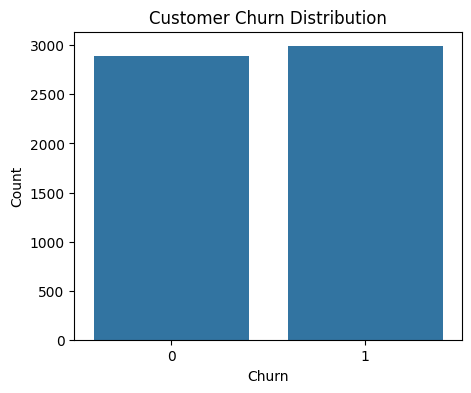

In [11]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=customer_df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [12]:
customer_df["churn"].value_counts(normalize=True) * 100

churn
1    50.850629
0    49.149371
Name: proportion, dtype: float64

In [13]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "avg_basket_size",
    "total_products",
    "unique_products",
    "product_diversity",
    "customer_lifetime_days",
    "avg_purchase_interval",
    "avg_revenue_per_product",
    "revenue_per_order",
    "products_per_order"
]

X = customer_df[features]
y = customer_df["churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (5878, 13)
Target Shape: (5878,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4702, 13)
(1176, 13)


In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [17]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [18]:
def evaluate_model(name, y_true, y_pred, y_prob):

    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print("ROC AUC  :", round(roc_auc_score(y_true, y_prob), 4))

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

In [20]:
evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred,
    log_prob
)
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


Logistic Regression
Accuracy : 0.9855
Precision: 1.0
Recall   : 0.9716
F1 Score : 0.9856
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       578
           1       1.00      0.97      0.99       598

    accuracy                           0.99      1176
   macro avg       0.99      0.99      0.99      1176
weighted avg       0.99      0.99      0.99      1176

XGBoost
Accuracy : 0.9983
Precision: 0.9983
Recall   : 0.9983
F1 Score : 0.9983
ROC AUC  : 1.0

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       578
           1       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



NameError: name 'rf_pred' is not defined

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results.sort_values("ROC AUC", ascending=False)